In [19]:
# Connect to Cassandra (container: my_cassandra)
from cassandra.cluster import Cluster

cluster = Cluster(['localhost'], port=9042)  # Same port as opened in 'docker run -p 9042:9042'
session = cluster.connect()                   # A session is used to send CQL queries


In [20]:
# Create a keyspace for the project (first time only)
# SimpleStrategy + replication_factor 1: the data is stored once
session.execute("""
    CREATE KEYSPACE IF NOT EXISTS ind320
    WITH REPLICATION = {'class': 'SimpleStrategy', 'replication_factor': 1};
""")

In [21]:
# List all keyspaces to confirm that 'ind320' was created
rows = session.execute("SELECT keyspace_name FROM system_schema.keyspaces;")
for row in rows:
    print(row.keyspace_name)

ind320
system_auth
system_schema
system_distributed
system
system_traces


In [22]:
# Environment variables for PySpark (system dependent)
import os, sys

# Java 17 (Microsoft OpenJDK) – path without \bin\java.exe
os.environ["JAVA_HOME"] = r"C:\Program Files\Microsoft\jdk-17.0.20.101-hotspot"
# Make Spark use the same Python as this notebook (.venv), not the system Python
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [23]:
# Start a Spark session with the Spark-Cassandra connector
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('IND320_part2').\
    config('spark.jars.packages', 'com.datastax.spark:spark-cassandra-connector_2.12:3.5.1').\
    config('spark.cassandra.connection.host', 'localhost').\
    config('spark.cassandra.connection.port', '9042').\
    config('spark.sql.extensions', 'com.datastax.spark.connector.CassandraSparkExtensions').\
    config('spark.sql.catalog.mycatalog', 'com.datastax.spark.connector.datasource.CassandraCatalog').\
    getOrCreate()

In [24]:
# Create a small test table in Cassandra and insert one row
session.execute("CREATE TABLE IF NOT EXISTS ind320.test (id int PRIMARY KEY, name text);")
session.execute("INSERT INTO ind320.test (id, name) VALUES (1, 'hello spark');")

# Read the same table through Spark
spark.read.format("org.apache.spark.sql.cassandra").\
    options(table="test", keyspace="ind320").load().show()

+---+-----------+
| id|       name|
+---+-----------+
|  1|hello spark|
+---+-----------+



In [25]:
   # Read the MongoDB connection string from .streamlit/secrets.toml 
   import tomllib
   from pymongo import MongoClient

   with open(".streamlit/secrets.toml", "rb") as f:
       secrets = tomllib.load(f)

   client = MongoClient(secrets["mongo"]["uri"])
   client.admin.command("ping")  # Raises an error if the connection fails
   print("Connected to MongoDB")

Connected to MongoDB


## Reservoir statistics from the NVE API
The CSV file from part 1 is replaced by a direct connection to NVE's Magasinstatistikk API
(https://biapi.nve.no/magasinstatistikk). 

In [26]:
# Imports for the API part
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Base URL shared by all Magasinstatistikk endpoints
NVE_BASE_URL = "https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk"

def get_nve(endpoint):
    """Call one endpoint of the NVE Magasinstatistikk API and return the JSON response."""
    response = requests.get(f"{NVE_BASE_URL}/{endpoint}", timeout=30)
    response.raise_for_status()  # Stop with an error if the request failed (e.g. 404/500)
    return response.json()

In [27]:
# HentOmråder returns a list with ONE dictionary containing three groups:
# 'land' (whole country), 'elspot' (price areas NO1-NO5) and 'vassdrag' (watercourse areas)
areas_json = get_nve("HentOmråder")[0]

# Combine the three groups into one table
areas = pd.concat(
    [pd.DataFrame(areas_json[group]) for group in ["land", "elspot", "vassdrag"]],
    ignore_index=True,
)

pd.set_option("display.max_colwidth", None)  # Show the full description text
areas[["omrType", "omrnr", "navn", "navn_langt", "beskrivelse"]]

,omrType,omrnr,navn,navn_langt,beskrivelse
0,NO,0,Norge,Norge,Hele landet
1,EL,1,NO 1,Elspotområde 1,Sørøst-Norge. Omfatter østlige del av Østlandet fra Buskerud og nordover (bortsett fra den del av Innlandet som ligger vest og nord for Vågåmo).
2,EL,2,NO 2,Elspotområde 2,"Sørvest-Norge. Omfatter mesteparten av Vestfold, Telemark, Agder, Rogaland og sørlige del av Vestland."
3,EL,3,NO 3,Elspotområde 3,"Midt-Norge. Omfatter nordre og vestlige del av Vestland, den del av Innlandet som ligger vest og nord for Vågåmo, Møre og Romsdal og Trøndelag til Tunnsjødal."
4,EL,4,NO 4,Elspotområde 4,Nord-Norge. Omfatter resten av Trøndelag og Nord-Norge.
5,EL,5,NO 5,Elspotområde 5,"Vest-Norge. Omfatter midtre del av Vestland opp til Sognefjorden og Indre Sogn, og vestlig del av Buskerud."
6,VASS,1,VASS1,Vassdragsområde 1,"Sørøst-Norge. Østlandet, Agder og deler av Rogaland."
7,VASS,2,VASS2,Vassdragsområde 2,Vest-Norge. Resten av Rogaland og Vestland.
8,VASS,3,VASS3,Vassdragsområde 3,"Midt-Norge. Møre og Romsdal, Trøndelag og sørlige Nordland"
9,VASS,4,VASS4,Vassdragsområde 4,Nord-Norge. Resten av Nordland og nordover.


In [28]:
# Which areas actually have data, and for which period?
# Compare with the area list from HentOmråder above (which lists 4 VASS areas)
coverage = (
    df_all.groupby(["area_type", "area_number"])["date"]
    .agg(first_date="min", last_date="max", weeks="count")
    .reset_index()
)
coverage

,area_type,area_number,first_date,last_date,weeks
0,EL,1,1995-01-08,2026-10-04,1657
1,EL,2,1995-01-08,2026-10-04,1657
2,EL,3,1995-01-08,2026-10-04,1657
3,EL,4,1995-01-08,2026-10-04,1657
4,EL,5,1995-01-08,2026-10-04,1657
5,NO,0,1995-01-08,2026-10-04,1657
6,VASS,1,1995-01-08,2026-10-04,1657
7,VASS,2,1995-01-08,2026-10-04,1657
8,VASS,3,1995-01-08,2026-10-04,1657


In [29]:
# Check: do the areas within each type add up to the national capacity?
latest = df_all[df_all["date"] == df_all["date"].max()]
latest.groupby("area_type")["capacity_TWh"].sum()

area_type
EL      87.437581
NO      87.437580
VASS    87.437582
Name: capacity_TWh, dtype: float64

### Areas covered by the API
The `HentOmråder` endpoint defines three types of areas:
- **NO (area 0):** Norway as a whole (national total).
- **EL (areas 1-5):** the electricity price areas NO1-NO5 (south-east, south-west,
  central, north and west Norway).
- **VASS (areas 1-4):** watercourse areas, grouping reservoirs by geography rather than
  by price area.

The coverage table shows that all nine series with data are complete and equally long:
1657 weekly observations from 1995-01-08 to the latest publication. There are no gaps,
so the areas can be compared directly week by week.

One difference from the area list: **VASS 4 (northern Norway) has no data**, even though
`HentOmråder` lists it. The capacities of VASS 1-3 still add up to the national capacity
(87.44 TWh), as do EL 1-5. This means the three VASS areas together cover all
reservoirs, so the reservoirs in the north seem to be included in the other VASS areas
in the published statistics.

Each area type is therefore a complete split of the national total, just divided in
different ways (price areas vs. watercourses).

In [30]:
# Download the full reservoir history (replaces pd.read_csv("data/reservoirs.csv") from part 1)
df = pd.DataFrame(get_nve("HentOffentligData"))

print(df.shape)
df.head()

(14913, 11)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [31]:
# Check columns and data types - compare with df.info() for the CSV file in part 1
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14913 entries, 0 to 14912
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14913 non-null  str    
 1   omrType                   14913 non-null  str    
 2   omrnr                     14913 non-null  int64  
 3   iso_aar                   14913 non-null  int64  
 4   iso_uke                   14913 non-null  int64  
 5   fyllingsgrad              14913 non-null  float64
 6   kapasitet_TWh             14913 non-null  float64
 7   fylling_TWh               14913 non-null  float64
 8   neste_Publiseringsdato    14913 non-null  str    
 9   fyllingsgrad_forrige_uke  14913 non-null  float64
 10  endring_fyllingsgrad      14913 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


### Cleaning the API data
Same cleaning as in part 1, but all areas are kept
The national total (NO, area 0) is then extracted to recreate the plots from part 1.

In [32]:
# English column names (same names as in part 1, plus the area columns that are kept now)
column_names = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "fyllingsgrad": "fill_ratio",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "fill_TWh",
    "fyllingsgrad_forrige_uke": "fill_ratio_previous_week",
    "endring_fyllingsgrad": "fill_ratio_change",
}

data_columns = [
    "fill_ratio",
    "capacity_TWh",
    "fill_TWh",
    "fill_ratio_previous_week",
    "fill_ratio_change",
]

# Keep only the columns we use. This drops iso_aar/iso_uke (same info as the date) and
# neste_Publiseringsdato (contains the placeholder 0001-01-01, which pandas cannot parse)
df_all = df.rename(columns=column_names)[list(column_names.values())].copy()

# Convert the date from text to datetime and sort chronologically
df_all["date"] = pd.to_datetime(df_all["date"])
df_all = df_all.sort_values(["area_type", "area_number", "date"]).reset_index(drop=True)

df_all.head()

,date,area_type,area_number,fill_ratio,capacity_TWh,fill_TWh,fill_ratio_previous_week,fill_ratio_change
0,1995-01-08,EL,1,0.617574,6.003264,3.707457,0.583705,0.033869
1,1995-01-15,EL,1,0.579205,6.003264,3.477117,0.617574,-0.038369
2,1995-01-22,EL,1,0.546713,6.003264,3.282063,0.579205,-0.032491
3,1995-01-29,EL,1,0.504545,6.003264,3.028916,0.546713,-0.042168
4,1995-02-05,EL,1,0.465335,6.003264,2.793528,0.504545,-0.039210


In [33]:
# National total (NO, area 0): one clean weekly time series, as in part 1
df_national = df_all[(df_all["area_type"] == "NO") & (df_all["area_number"] == 0)]
df_national = df_national[["date"] + data_columns].reset_index(drop=True)

print(f"Rows in national series: {len(df_national)}")
df_national.tail()

Rows in national series: 1657


,date,fill_ratio,capacity_TWh,fill_TWh,fill_ratio_previous_week,fill_ratio_change
1652,2026-09-06,0.636207,87.43758,55.628372,0.634423,0.001784
1653,2026-09-13,0.642904,87.43758,56.213930,0.636209,0.006695
1654,2026-09-20,0.666386,87.43758,58.267190,0.642900,0.023486
1655,2026-09-27,0.678489,87.43758,59.325410,0.666364,0.012124
1656,2026-10-04,0.678859,87.43758,59.357765,0.678495,0.000364


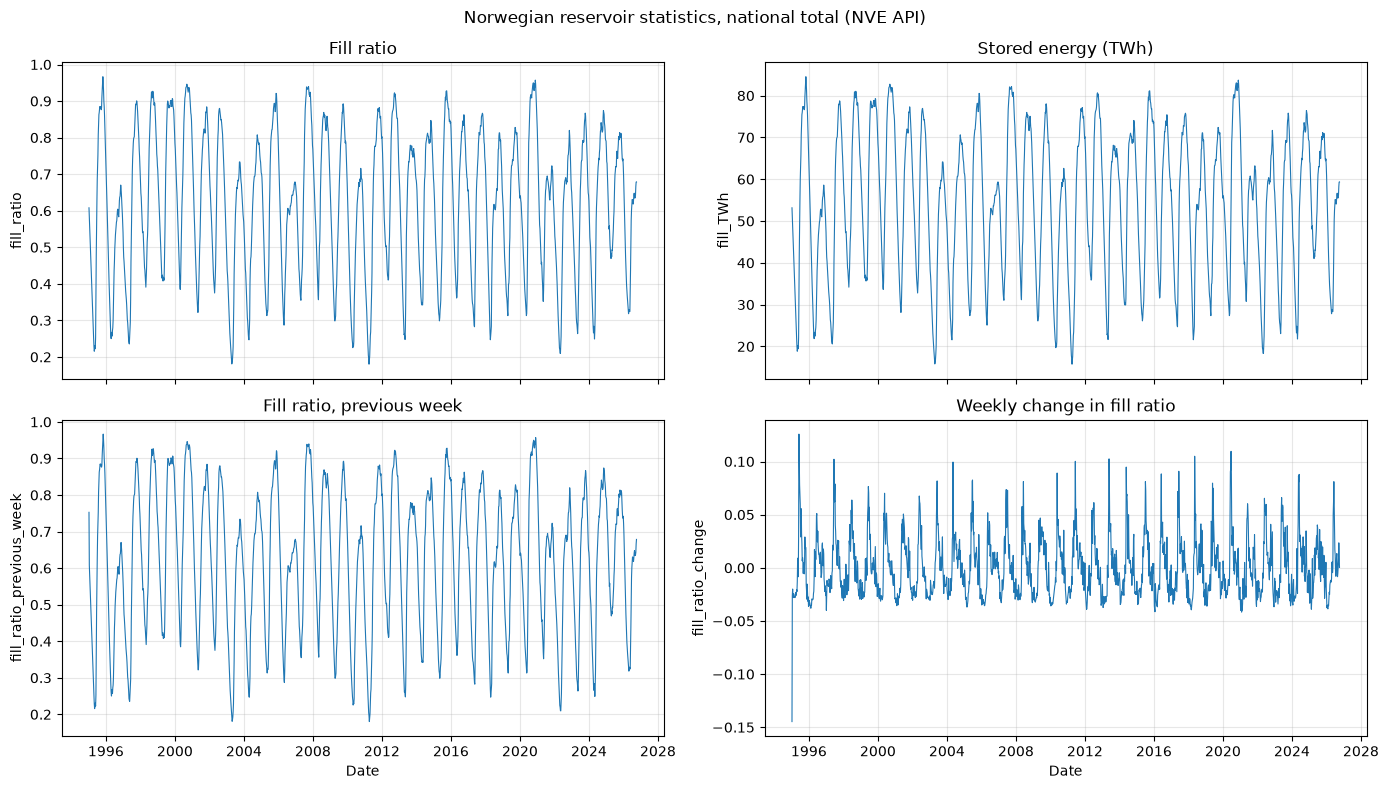

In [34]:
# capacity_TWh is constant at national level (87.44 TWh), so it is left out of the plots
plot_columns = ["fill_ratio", "fill_TWh", "fill_ratio_previous_week", "fill_ratio_change"]
plot_titles = ["Fill ratio", "Stored energy (TWh)", "Fill ratio, previous week", "Weekly change in fill ratio"]

# 2x2 grid keeps the figure compact (fits on one PD
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, column, title in zip(axes.flatten(), plot_columns, plot_titles):
    ax.plot(df_national["date"], df_national[column], linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel(column)
    ax.grid(alpha=0.3)

# Only the bottom row needs an x-label when the x-axis is shared
for ax in axes[1]:
    ax.set_xlabel("Date")

fig.suptitle("Norwegian reservoir statistics, national total (NVE API)")
fig.tight_layout()
plt.show()

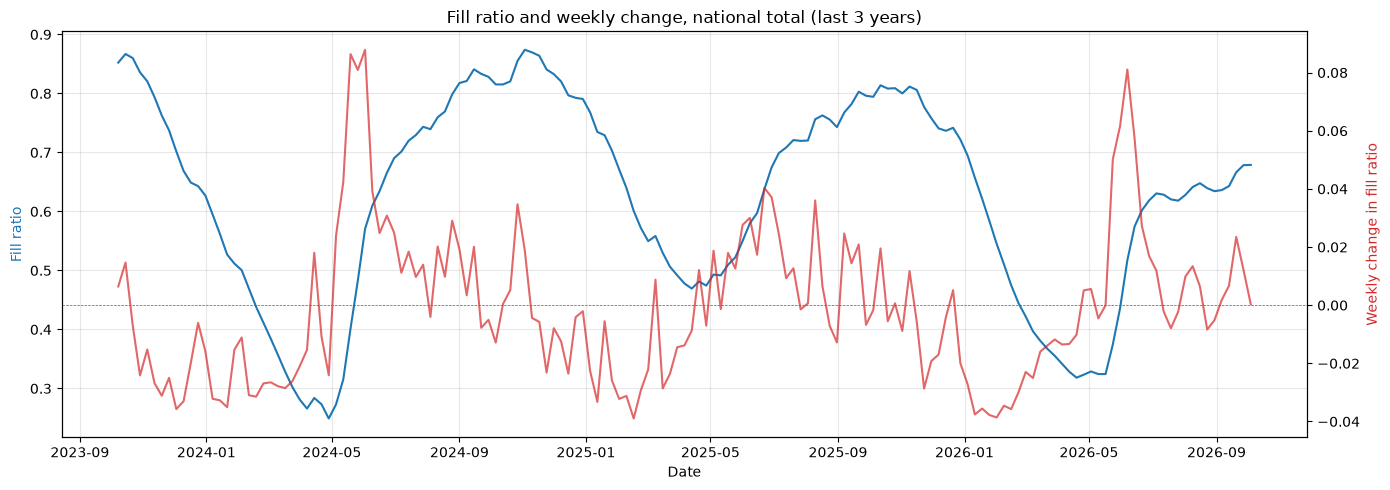

In [35]:
# Fill ratio and weekly change on separate y-axes: the other columns are derived from
# fill_ratio (fill_TWh = fill_ratio x capacity, previous week = fill_ratio shifted one week),
# so these two carry the information. Last 3 years only, so the seasonal pattern is readable.
recent = df_national[df_national["date"] >= df_national["date"].max() - pd.DateOffset(years=3)]

fig, ax1 = plt.subplots(figsize=(14, 5))

# Left y-axis: fill ratio (0-1)
ax1.plot(recent["date"], recent["fill_ratio"], color="tab:blue", label="Fill ratio")
ax1.set_xlabel("Date")
ax1.set_ylabel("Fill ratio", color="tab:blue")
ax1.grid(alpha=0.3)

# Right y-axis: weekly change (can be negative, so it gets its own scale)
ax2 = ax1.twinx()
ax2.plot(recent["date"], recent["fill_ratio_change"], color="tab:red", alpha=0.7, label="Weekly change")
ax2.axhline(0, color="tab:red", linewidth=0.5, linestyle="--")  # Zero line: filling vs. emptying
ax2.set_ylabel("Weekly change in fill ratio", color="tab:red")

ax1.set_title("Fill ratio and weekly change, national total (last 3 years)")
fig.tight_layout()
plt.show()